# Notebook principal — INF6243

Ce notebook exécute le pipeline complet et affiche les résultats clés.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image

import sys
sys.path.insert(0, "Code")
from main import run_pipeline

In [ ]:
# Constantes transversales d'exécution
# MAX_SAMPLES: int (>0) pour sous-échantillonner, ou None pour utiliser 100% des données.
MAX_SAMPLES = 12000

# DISTILBERT_EPOCHS: nombre d'epochs DistilBERT (1=rapide, 2-4=plus long et potentiellement meilleur).
DISTILBERT_EPOCHS = 2

# INCLUDE_DISTILBERT: True pour inclure DistilBERT dans la comparaison, False pour l'ignorer.
INCLUDE_DISTILBERT = True

# TEST_SIZE: proportion du jeu de test (entre 0 et 1), ex: 0.2 = 20%.
TEST_SIZE = 0.2

# VAL_SIZE: proportion du jeu de validation (entre 0 et 1), ex: 0.1 = 10%.
VAL_SIZE = 0.1

# CV_FOLDS: nombre de folds pour la validation croisée des modèles compatibles.
CV_FOLDS = 5

# SCORING: métrique optimisée dans GridSearchCV (ex: "f1_macro", "accuracy").
SCORING = "f1_macro"

# SELECTION_WEIGHTS: pondérations (validation, test, cv) utilisées pour le score final.
# La somme doit idéalement valoir 1.0.
SELECTION_WEIGHTS = (0.35, 0.40, 0.25)

# RANDOM_STATE: seed globale pour reproductibilité des splits et des modèles stochastiques.
RANDOM_STATE = 42

RUN_CONFIG = {
    "max_samples": MAX_SAMPLES,
    "distilbert_epochs": DISTILBERT_EPOCHS,
    "include_distilbert": INCLUDE_DISTILBERT,
    "test_size": TEST_SIZE,
    "val_size": VAL_SIZE,
    "cv_folds": CV_FOLDS,
    "scoring": SCORING,
    "selection_weights": SELECTION_WEIGHTS,
    "random_state": RANDOM_STATE,
}

artifacts = run_pipeline(**RUN_CONFIG)
artifacts

Device détecté (pour deep learning): cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/8400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.319392,0.293463


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

{'best_model_name': 'RandomForest',
 'best_model_path': "/home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs/models/best_model.joblib",
 'report_path': "/home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs/reports/metrics_report.json",
 'figures_dir': "/home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs/figures",
 'outputs_dir': "/home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs"}

In [3]:
report_path = Path(artifacts["report_path"])
with report_path.open("r", encoding="utf-8") as file:
    report = json.load(file)

print("Meilleur modèle:", report.get("best_model"))
print("Métriques test:", report.get("best_model_test_metrics"))
print("DistilBERT:", report.get("distilbert_note"))
print("Configuration:", report.get("run_config"))
display(Markdown("**Justification:** " + report.get("best_model_selection_explanation", "")))

Meilleur modèle: RandomForest
Métriques test: {'accuracy': 0.875, 'precision_macro': 0.7018698521791306, 'recall_macro': 0.7561776759101173, 'f1_macro': 0.725038019844059}
DistilBERT: DistilBERT inclus dans la comparaison.
Configuration: {'max_samples': 12000, 'distilbert_epochs': 1, 'include_distilbert': True, 'test_size': 0.2, 'val_size': 0.1, 'cv_folds': 5, 'scoring': 'f1_macro', 'selection_weights': [0.35, 0.4, 0.25], 'random_state': 42}


**Justification:** Le modèle RandomForest obtient le meilleur score global pondéré (0.7212) en combinant validation, test et CV. Il est retenu pour son compromis entre performance et robustesse.

In [4]:
# Tableau complet: tous les modèles, statut, métriques, hyperparamètres
rows = []
for model_name in report.get("expected_models", []):
    payload = report.get("all_models", {}).get(model_name, {})
    rows.append({
        "model": model_name,
        "status": payload.get("status"),
        "error_or_reason": payload.get("error"),
        "selection_score": payload.get("selection_score"),
        "val_f1_macro": payload.get("validation_metrics", {}).get("f1_macro"),
        "test_f1_macro": payload.get("test_metrics", {}).get("f1_macro"),
        "cv_f1_macro_mean": payload.get("cv_f1_macro_mean"),
        "representation": payload.get("feature_config", {}).get("representation"),
        "best_cv_score": payload.get("tuning", {}).get("best_cv_score"),
        "best_params": str(payload.get("tuning", {}).get("best_params", {})),
    })

pd.DataFrame(rows).sort_values(["status", "selection_score"], ascending=[True, False])

,model,status,error_or_reason,selection_score,val_f1_macro,test_f1_macro,cv_f1_macro_mean,representation,best_cv_score,best_params
5,RandomForest,trained,None,0.721170,0.722034,0.725038,0.713770,TF-IDF sparse vectors,0.715079,"{'clf__max_depth': None, 'clf__max_features': ..."
2,LinearSVC,trained,None,0.714181,0.709089,0.720859,0.710624,TF-IDF sparse vectors,0.711255,"{'clf__C': 0.5, 'tfidf__min_df': 2, 'tfidf__ng..."
1,LogisticRegression,trained,None,0.711045,0.695444,0.727255,0.706950,TF-IDF sparse vectors,0.704737,"{'clf__C': 1.0, 'tfidf__min_df': 2, 'tfidf__ng..."
4,DecisionTree,trained,None,0.676294,0.661335,0.685790,0.682042,TF-IDF sparse vectors,0.682303,"{'clf__ccp_alpha': 0.0, 'clf__max_depth': 40, ..."
7,DistilBERT,trained,None,0.616932,0.611736,0.624725,0.611736,Transformer embeddings,NaN,"{'model_name': 'distilbert-base-uncased', 'epo..."
6,MLPClassifier,trained,None,0.551305,0.544153,0.549799,0.563727,TF-IDF sparse vectors,0.584219,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size..."
3,KNN,trained,None,0.522192,0.536812,0.543823,0.467116,TF-IDF sparse vectors,0.519302,"{'clf__n_neighbors': 11, 'clf__weights': 'unif..."
0,NaiveBayes,trained,None,0.505844,0.522899,0.497841,0.494772,TF-IDF sparse vectors,0.493459,"{'clf__alpha': 0.5, 'tfidf__min_df': 5, 'tfidf..."


In [5]:
# Interpréteur de résultats (diagnostic + recommandations)
all_models = report.get("all_models", {})
status_counts = pd.Series([payload.get("status", "unknown") for payload in all_models.values()]).value_counts()


def _fmt(value):
    return "n/a" if value is None else f"{float(value):.4f}"


print("=== INTERPRETATION RAPIDE ===")
print(f"Meilleur modèle: {report.get('best_model')}")
print(f"Score de sélection: {_fmt(report.get('best_model_selection_score'))}")
print("\nStatuts des modèles:")
print(status_counts.to_string())

trained = [name for name, payload in all_models.items() if payload.get("status") == "trained"]
ranking = report.get("model_selection_ranking", [])
if trained:
    print("\nTop 3 modèles (score global):", ranking[:3])

print("\nDiagnostic par modèle entraîné:")
for name in ranking:
    payload = all_models.get(name, {})
    if payload.get("status") != "trained":
        continue

    val_f1 = payload.get("validation_metrics", {}).get("f1_macro")
    test_f1 = payload.get("test_metrics", {}).get("f1_macro")
    cv_mean = payload.get("cv_f1_macro_mean")
    selection_score = payload.get("selection_score")

    # Analyse simple de généralisation: val vs test.
    gap = None if val_f1 is None or test_f1 is None else float(val_f1 - test_f1)
    if gap is None:
        diagnosis = "incomplet"
    elif gap > 0.05:
        diagnosis = "possible surapprentissage"
    elif gap < -0.05:
        diagnosis = "possible sous-ajustement / split favorable test"
    else:
        diagnosis = "généralisation stable"

    # Stabilité CV: plus l'écart test-CV est faible, plus la robustesse est plausible.
    stability = None if cv_mean is None or test_f1 is None else abs(float(test_f1 - cv_mean))
    if stability is None:
        stability_note = "stabilité non disponible"
    elif stability <= 0.03:
        stability_note = "stabilité forte"
    elif stability <= 0.07:
        stability_note = "stabilité moyenne"
    else:
        stability_note = "stabilité faible"

    print(
        f"- {name}: selection={_fmt(selection_score)} | val_f1={_fmt(val_f1)} | "
        f"test_f1={_fmt(test_f1)} | cv_mean={_fmt(cv_mean)} | {diagnosis} | {stability_note}"
    )

weak_models = []
for name in trained:
    f1 = all_models[name].get("test_metrics", {}).get("f1_macro")
    if f1 is not None and f1 < 0.55:
        weak_models.append((name, f1))
if weak_models:
    print("\nModèles à améliorer (F1_macro test < 0.55):")
    for name, f1 in sorted(weak_models, key=lambda x: x[1]):
        print(f"- {name}: {f1:.4f}")

print("\nRecommandations automatiques:")
if weak_models:
    print("- Augmenter la taille d'échantillon (MAX_SAMPLES=None) avant nouveau tuning.")
print("- Tester CV_FOLDS=3 pour runs rapides, puis 5 pour consolidation finale.")
print("- Ajuster SELECTION_WEIGHTS si l'objectif priorise robustesse (augmenter poids CV).")
print("- Pour DistilBERT, augmenter DISTILBERT_EPOCHS progressivement (1 -> 2 -> 3).")

print("\nDistilBERT:", report.get("distilbert_note"))
print("=== FIN INTERPRETATION ===")

=== INTERPRETATION RAPIDE ===
Meilleur modèle: RandomForest
Score de sélection: 0.7212

Statuts des modèles:
trained    8

Top 3 modèles (score global): ['RandomForest', 'LinearSVC', 'LogisticRegression']

Diagnostic par modèle entraîné:
- RandomForest: selection=0.7212 | val_f1=0.7220 | test_f1=0.7250 | cv_mean=0.7138 | généralisation stable | stabilité forte
- LinearSVC: selection=0.7142 | val_f1=0.7091 | test_f1=0.7209 | cv_mean=0.7106 | généralisation stable | stabilité forte
- LogisticRegression: selection=0.7110 | val_f1=0.6954 | test_f1=0.7273 | cv_mean=0.7069 | généralisation stable | stabilité forte
- DecisionTree: selection=0.6763 | val_f1=0.6613 | test_f1=0.6858 | cv_mean=0.6820 | généralisation stable | stabilité forte
- DistilBERT: selection=0.6169 | val_f1=0.6117 | test_f1=0.6247 | cv_mean=0.6117 | généralisation stable | stabilité forte
- MLPClassifier: selection=0.5513 | val_f1=0.5442 | test_f1=0.5498 | cv_mean=0.5637 | généralisation stable | stabilité forte
- KNN: sel

## Pourquoi `best_cv_score` peut être vide pour DistilBERT ?

- Les modèles classiques utilisent `GridSearchCV`, donc un `best_cv_score` est produit.
- DistilBERT est entraîné en fine-tuning direct (pas de GridSearchCV complet pour limiter le coût).
- Le fallback de robustesse est documenté dans `model_selection_method.cv_fallback_for_models`.

### models_compilation_overview.png

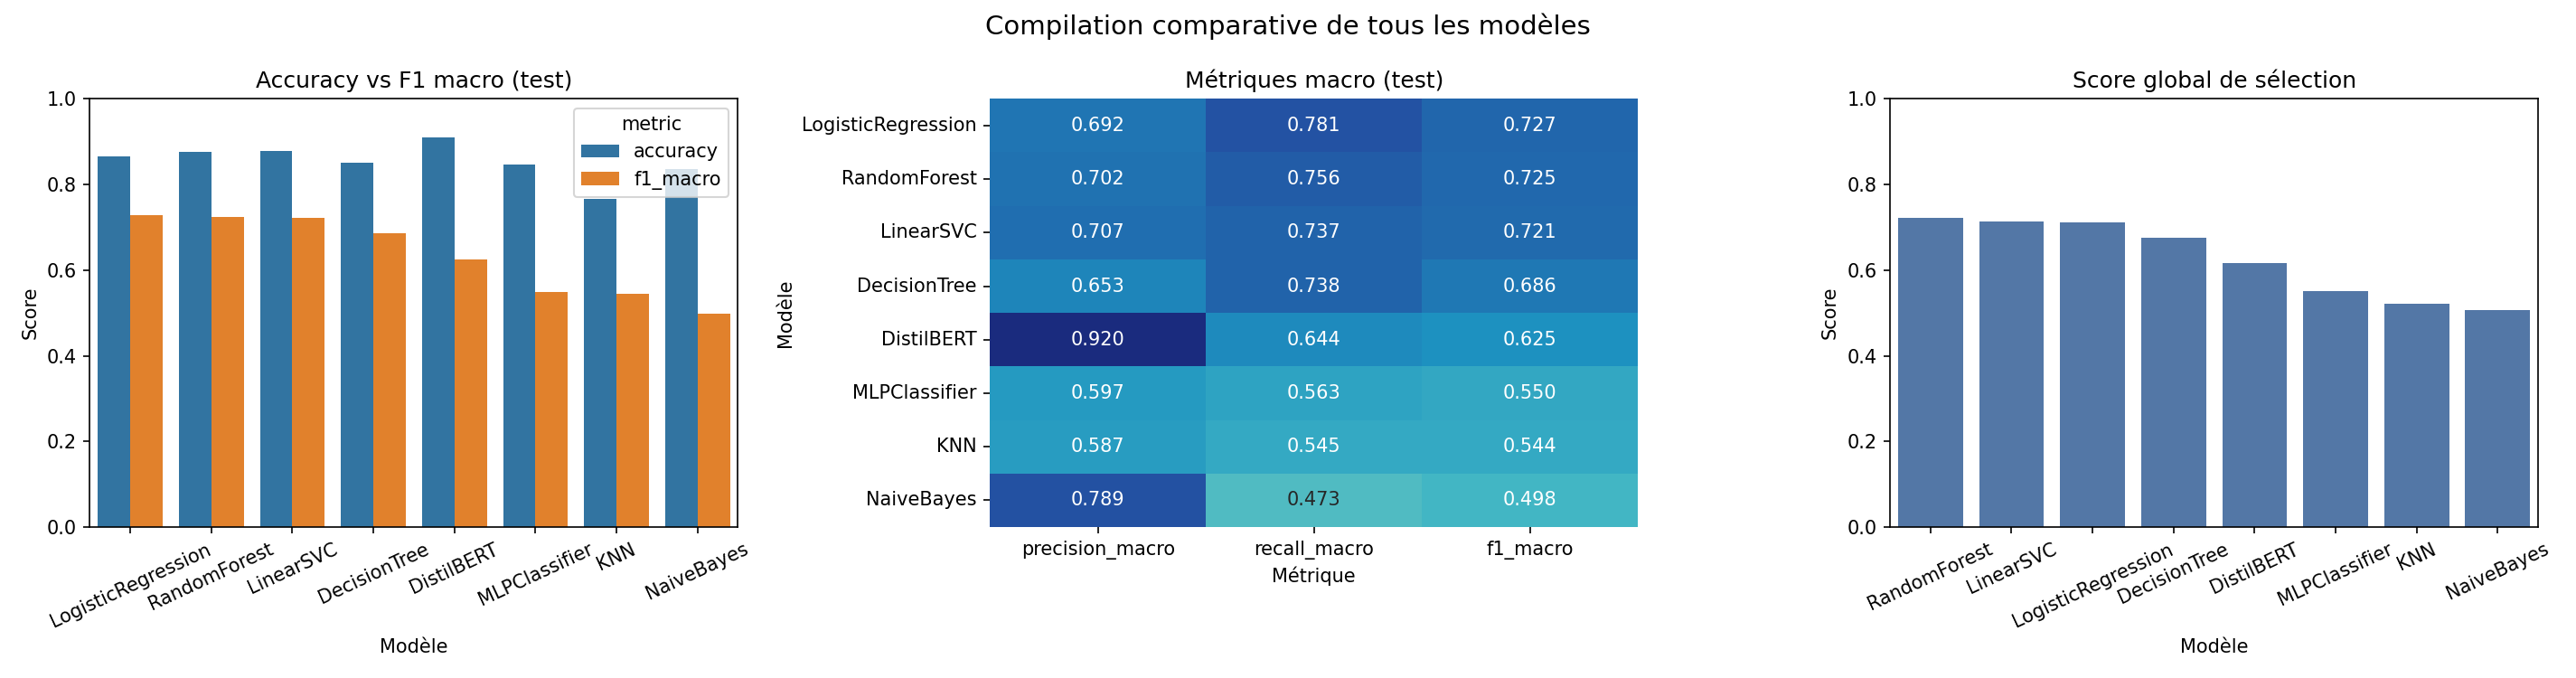

### models_status_overview.png

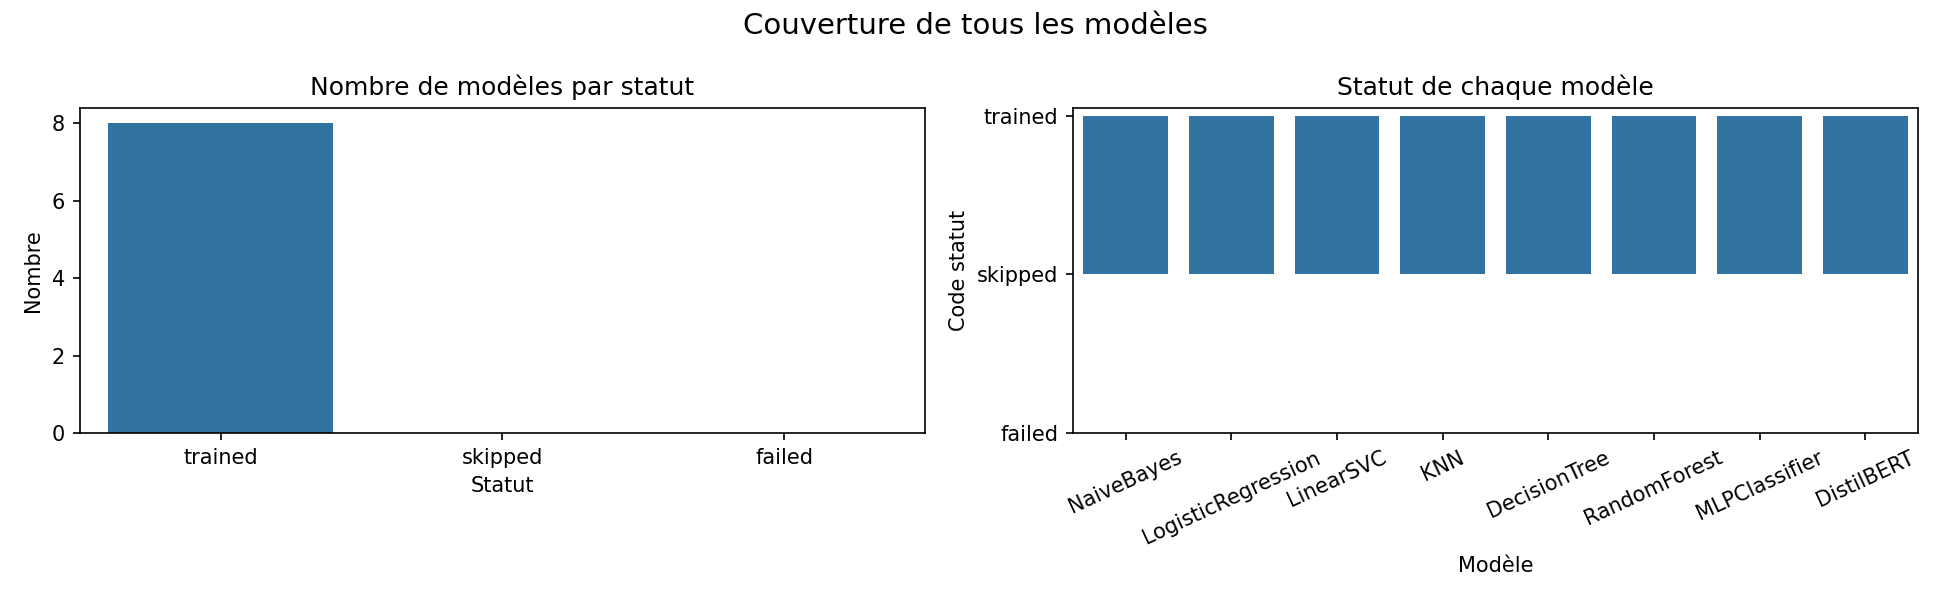

### confusion_matrices_all_models.png

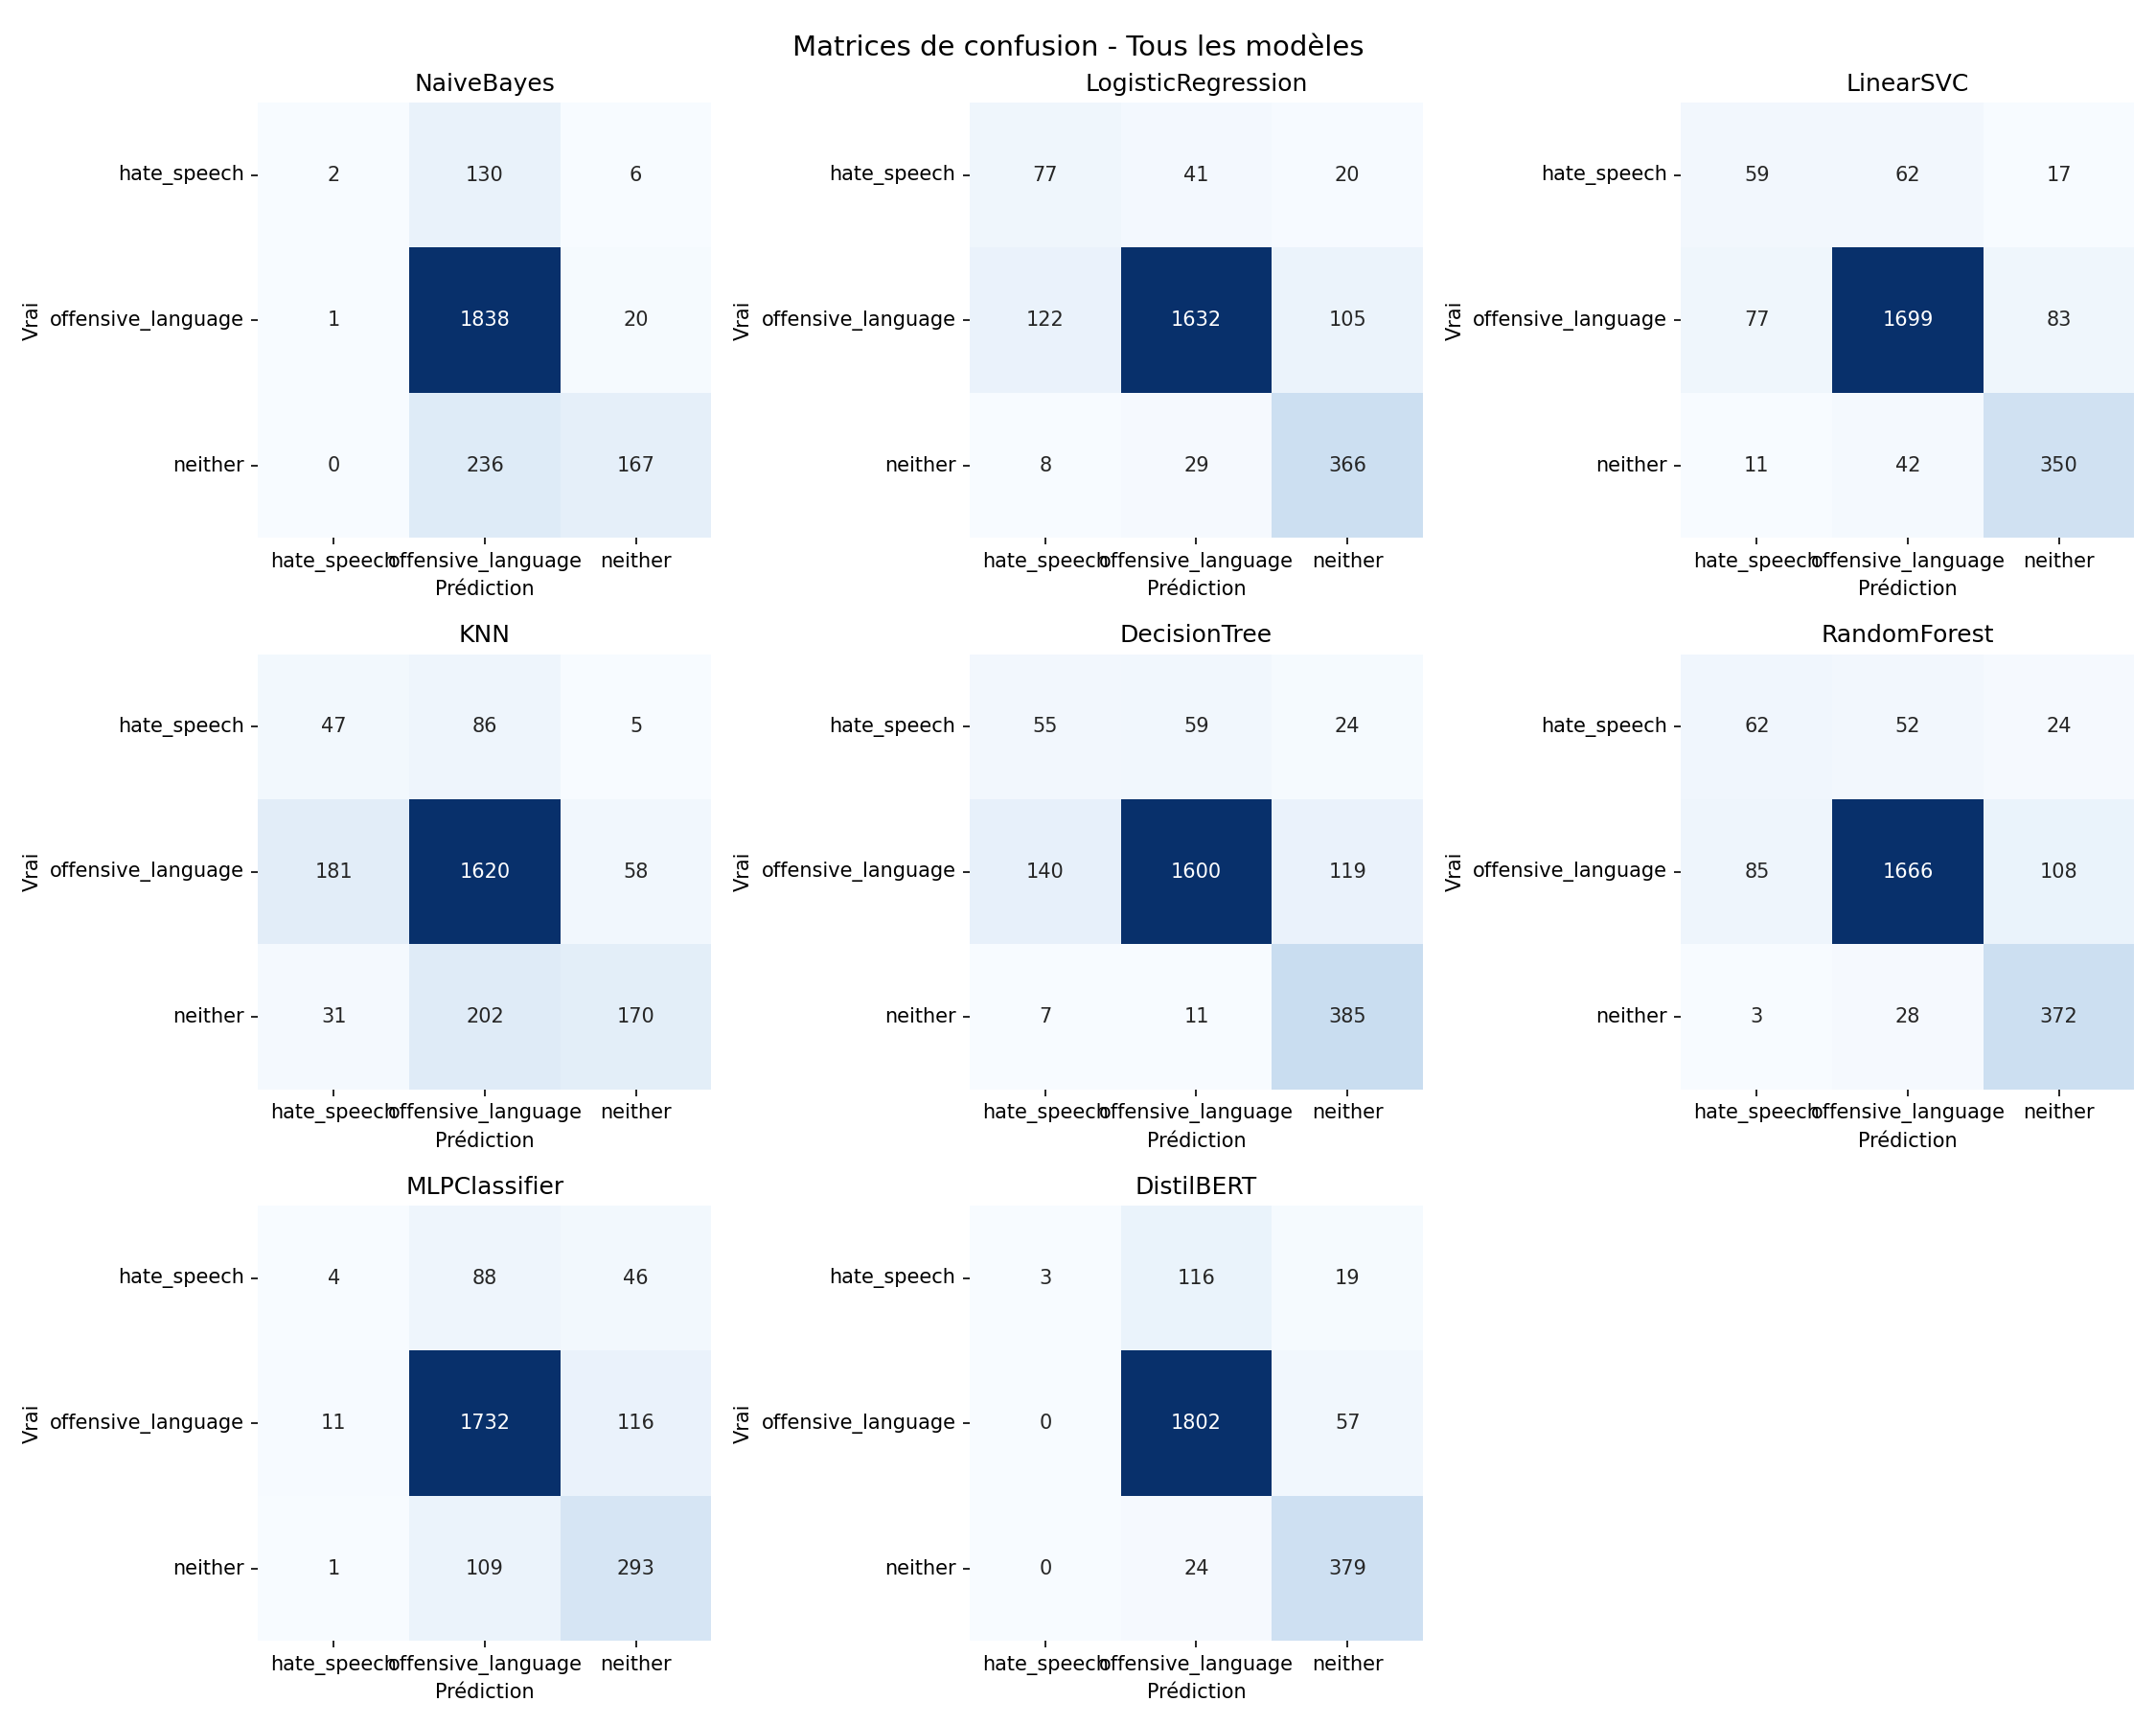

### models_comparison_test.png

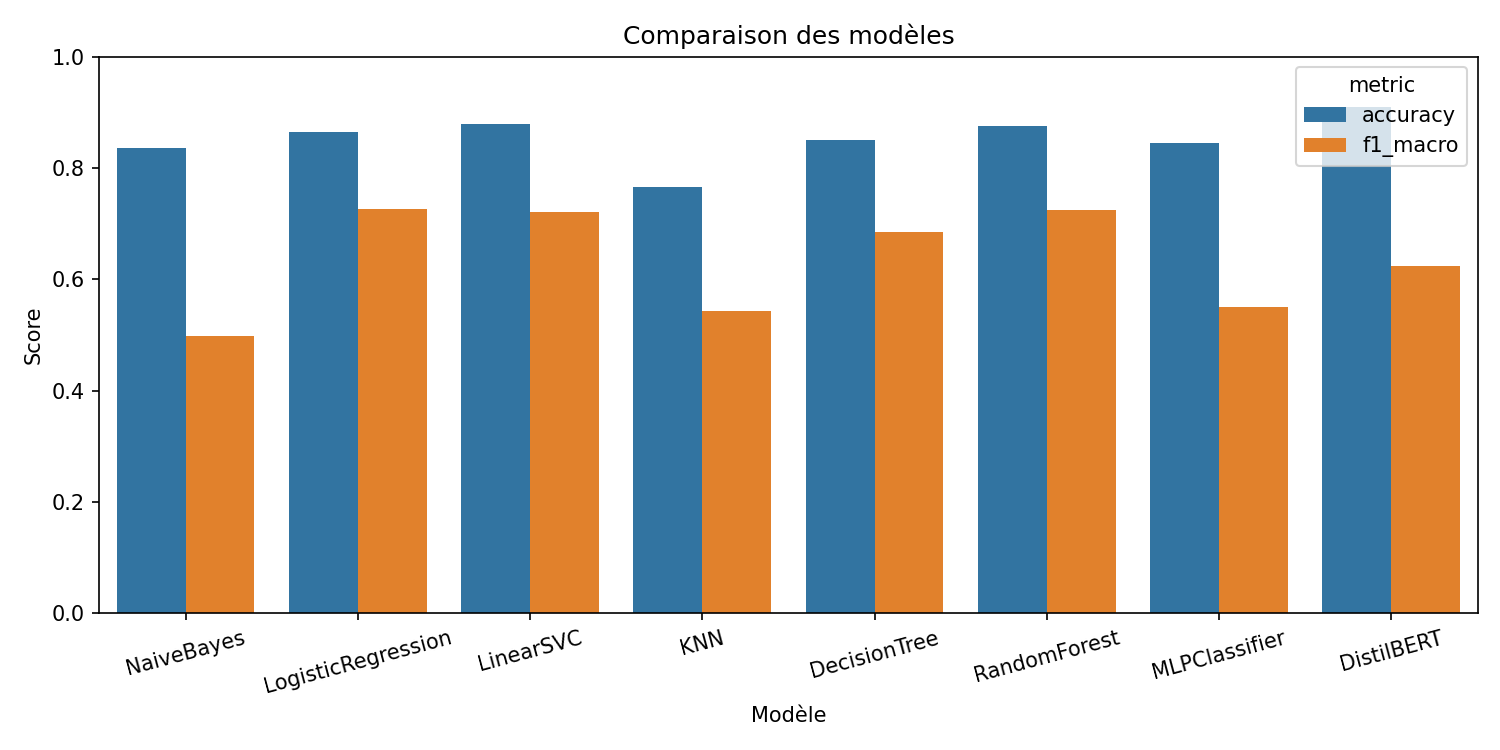

### learning_curve_best_model.png

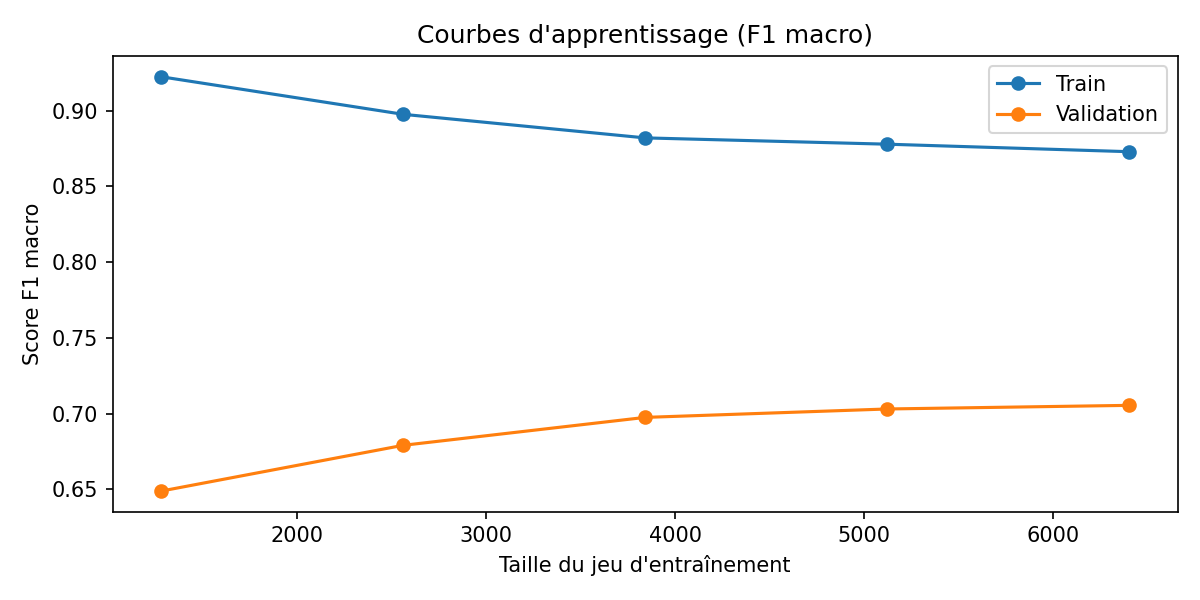

In [6]:
fig_dir = Path(artifacts["figures_dir"])
for fig_name in [
    "models_compilation_overview.png",
    "models_status_overview.png",
    "confusion_matrices_all_models.png",
    "models_comparison_test.png",
    "learning_curve_best_model.png",
]:
    fig_path = fig_dir / fig_name
    if fig_path.exists():
        display(Markdown(f"### {fig_name}"))
        display(Image(filename=str(fig_path)))
    else:
        print(f"Figure absente: {fig_path}")